In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
 71% 138M/195M [00:00<00:00, 1.43GB/s]
100% 195M/195M [00:00<00:00, 1.06GB/s]


In [ ]:
import os
import shutil

DATASET_PATH = "/content/data/Dataset_BUSI_with_GT"
OUTPUT_PATH = "/content/data/Dataset_BUSI_with_GT/train"

classes = ["benign", "malignant", "normal"]

os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    # Only include image files, exclude mask files
    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and "_mask" not in f.lower()
    ]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied (without masks).")

print("All class images copied into train folder (mask images removed).")

Class benign: 437 images copied (without masks).
Class malignant: 210 images copied (without masks).
Class normal: 133 images copied (without masks).
All class images copied into train folder (mask images removed).


In [ ]:
train_dir = "/content/data/Dataset_BUSI_with_GT/train"

Classes: ['normal', 'benign', 'malignant']


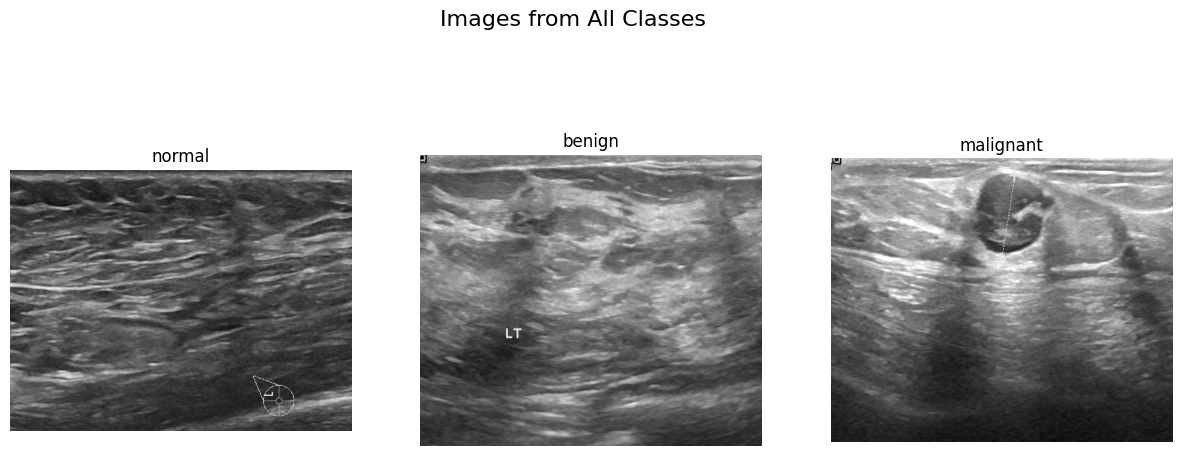

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(15, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(1, 3, i+1)  # 1 row, 5 columns

    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipython-input-3315502790.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=palette)


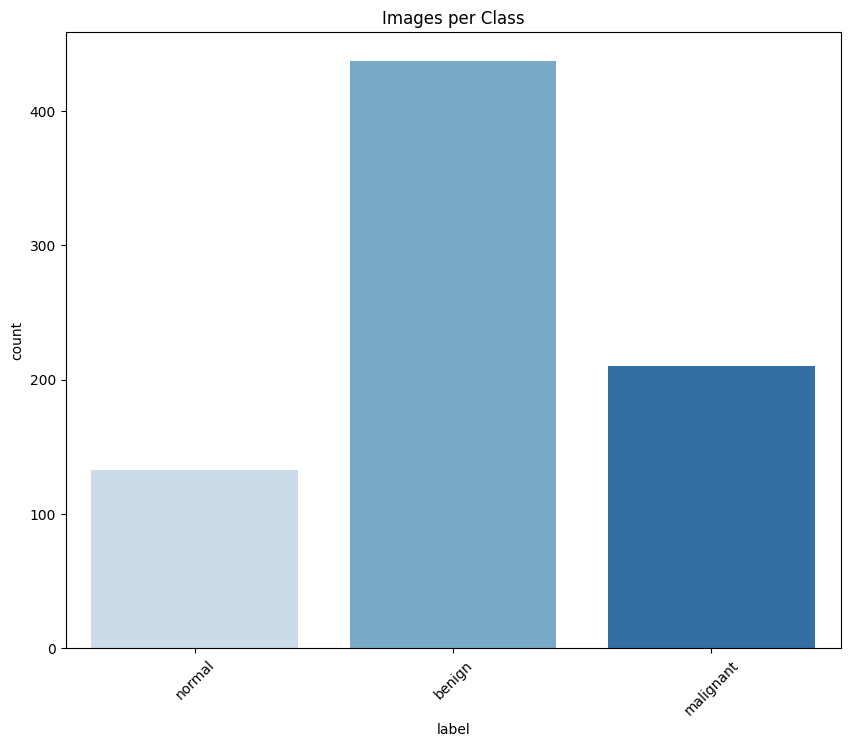

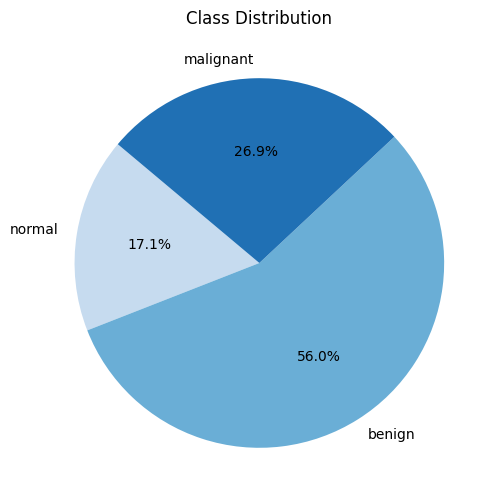

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Choose a blue-purple palette
palette = sns.color_palette("Blues", len(df))

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
    colors=palette
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()


# **Oversampling and Label Encoding**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import os

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

target_count = 450  # max images per class

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    current_count = len(images)

    if current_count >= target_count:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    needed = target_count - current_count
    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    for _ in range(needed):
        img_path = os.path.join(cls_path, images[img_index % len(images)])
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1, save_to_dir=cls_path, save_prefix="aug", save_format="jpg")
        next(aug_iter)
        img_index += 1

print("✅ Data augmentation completed.\n")

# Print final class counts
for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count} images")

Augmenting normal: generating 5 images...
Skipping benign: 450 images already present.
Augmenting malignant: generating 1 images...
✅ Data augmentation completed.

normal: 450 images
benign: 450 images
malignant: 450 images


In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

encoder = LabelEncoder()
df["Label_num"] = encoder.fit_transform(df["label"])

image_paths = []
labels_num = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels_num.append(encoder.transform([cls])[0])

df_balanced = pd.DataFrame({"image_path": image_paths, "label_num": labels_num})

print("Class counts after augmentation:")
print(df_balanced["label_num"].value_counts())

Class counts after augmentation:
label_num
2    450
0    450
1    450
Name: count, dtype: int64


# **Train-Test_Split**

In [ ]:
from sklearn.model_selection import train_test_split

df_balanced['label_num'] = df_balanced['label_num'].astype(str)

train_df, temp_df = train_test_split(df_balanced, train_size=0.8, shuffle=True,
                                     stratify=df_balanced['label_num'], random_state=42)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, shuffle=True,
                                     stratify=temp_df['label_num'], random_state=42)

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (1080, 2)
Validation size: (135, 2)
Test size: (135, 2)


# **Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

batch_size = 32
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    shear_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label_num',
    target_size=img_size, class_mode='sparse',
    color_mode='rgb', shuffle=True, batch_size=batch_size
)

valid_gen = test_datagen.flow_from_dataframe(
    valid_df, x_col='image_path', y_col='label_num',
    target_size=img_size, class_mode='sparse',
    color_mode='rgb', shuffle=False, batch_size=batch_size
)

test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label_num',
    target_size=img_size, class_mode='sparse',
    color_mode='rgb', shuffle=False, batch_size=batch_size
)

Found 1080 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.


# **Create MobileNetV2 Model , Train Model, Plot Accuracy & Loss, Evaluate on Test Set**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, LeakyReLU
from tensorflow.keras.optimizers import Adam

def create_mobilenetv2_optimized(input_shape=(224,224,3), num_classes=3):
    inputs = Input(shape=input_shape)
    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)

    # Fine-tune last 50 layers instead of 20
    for layer in base.layers[:-50]:
        layer.trainable = False
    for layer in base.layers[-50:]:
        layer.trainable = True

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(512)(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # slightly higher dropout

    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = create_mobilenetv2_optimized(num_classes=3)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/tmp/ipython-input-260103604.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,053,123 (11.65 MB)

 Trainable params: 2,646,659 (10.10 MB)

 Non-trainable params: 406,464 (1.55 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [ ]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=40,   # more epochs for better convergence
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4121 - loss: 1.8769
Epoch 1: val_accuracy improved from -inf to 0.34074, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.4143 - loss: 1.8671 - val_accuracy: 0.3407 - val_loss: 1.5837 - learning_rate: 1.0000e-04
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6540 - loss: 0.9907
Epoch 2: val_accuracy improved from 0.34074 to 0.34815, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.6543 - loss: 0.9890 - val_accuracy: 0.3481 - val_loss: 1.9041 - learning_rate: 1.0000e-04
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7463 - loss: 0.7594
Epoch 3: val_accuracy improved from 0.34815 to 0.38519, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.7460 - loss: 0.7598 - val_accuracy: 0.3852 - val_loss: 2.2114 - learning_rate: 1.0000e-04
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7340 - loss: 0.7349
Epoch 4: val_accuracy improved from 0.38519 to 0.42963, saving model to best_model.h5


...

34/34 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.9053 - loss: 0.2642 - val_accuracy: 0.7556 - val_loss: 0.7525 - learning_rate: 6.2500e-06
Epoch 34/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9051 - loss: 0.2883
Epoch 34: val_accuracy improved from 0.75556 to 0.77037, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9050 - loss: 0.2876 - val_accuracy: 0.7704 - val_loss: 0.7382 - learning_rate: 6.2500e-06
Epoch 35/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8890 - loss: 0.3613
Epoch 35: val_accuracy did not improve from 0.77037
34/34 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.8892 - loss: 0.3603 - val_accuracy: 0.7630 - val_loss: 0.7377 - learning_rate: 6.2500e-06
Epoch 36/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8976 - loss: 0.2827
Epoch 36: val_accuracy improved from 0.77037 to 0.78519, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8977 - loss: 0.2827 - val_accuracy: 0.7852 - val_loss: 0.7203 - learning_rate: 6.2500e-06
Epoch 37/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9026 - loss: 0.2627
Epoch 37: val_accuracy improved from 0.78519 to 0.79259, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.9029 - loss: 0.2622 - val_accuracy: 0.7926 - val_loss: 0.7021 - learning_rate: 6.2500e-06
Epoch 38/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9247 - loss: 0.1958
Epoch 38: val_accuracy did not improve from 0.79259
34/34 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9246 - loss: 0.1965 - val_accuracy: 0.7926 - val_loss: 0.7035 - learning_rate: 6.2500e-06
Epoch 39/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9215 - loss: 0.1919
Epoch 39: val_accuracy did not improve from 0.79259
34/34 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.9213 - loss: 0.1929 - val_accuracy: 0.7926 - val_loss: 0.6913 - learning_rate: 6.2500e-06
Epoch 40/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9167 - loss: 0.2434
Epoch 40: val_accuracy improved from 0.79259 to 0.80000, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9167 - loss: 0.2435 - val_accuracy: 0.8000 - val_loss: 0.6767 - learning_rate: 6.2500e-06
Restoring model weights from the end of the best epoch: 40.


In [ ]:
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8605 - loss: 0.3905
Final Test Accuracy: 84.44%
Final Test Loss: 0.4924


In [ ]:
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

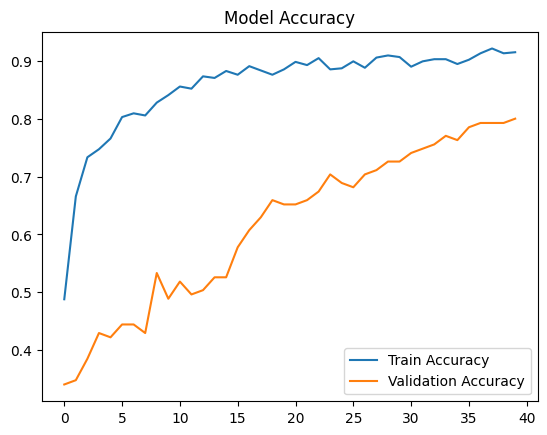

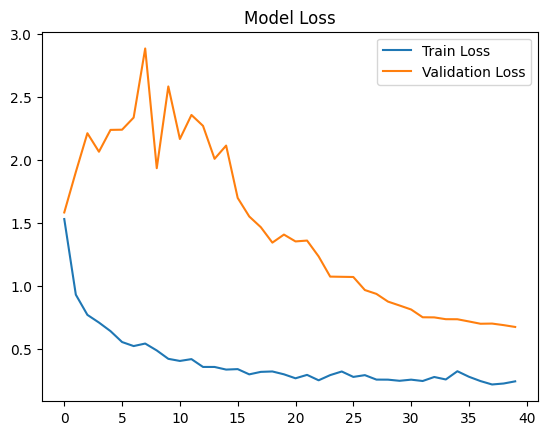

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        45
           1       0.75      0.98      0.85        45
           2       1.00      0.67      0.80        45

    accuracy                           0.84       135
   macro avg       0.87      0.84      0.84       135
weighted avg       0.87      0.84      0.84       135



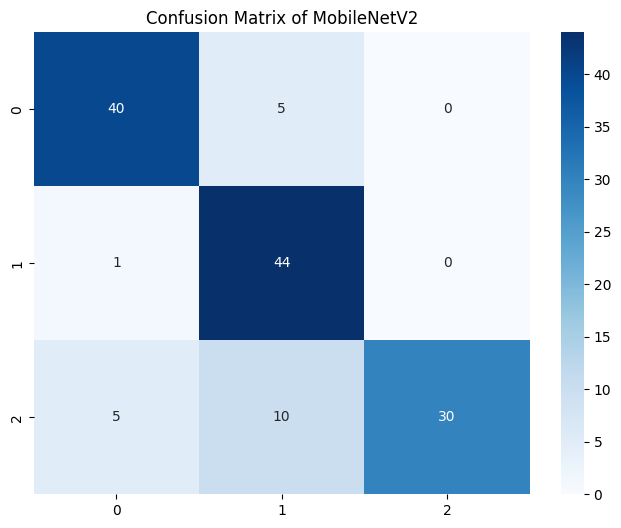

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of MobileNetV2")
plt.show()